# Supplementary Figure SR6 — clinical success against pleiotropy, ten trait counts

Supplementary Results 14.3 asks whether the non-linear relation between pleiotropy and clinical
success survives when "number of traits" is counted ten different ways — therapeutic areas and the
gPS disease count as published, then eight counts that decorrelate the trait list or restrict it to
the genetic-correlation matrix. One panel per count, same recipe in each.

**Recipe, unchanged from the main-text figure.** For each count: a logistic regression of approval on
genetic support, $\log(\text{count}+1)$ and its square; the fitted probability for pairs with GWAS
support (blue solid) and without (grey); a 95% band from 200 bootstrap resamples; and the empirical
LOWESS curve for the supported pairs with its own band (blue dashed). The horizontal axis is the
count on a log scale over its own range, the vertical axis is fixed at 0.1-0.5, and the rug marks the
supported pairs.

Ported from `chapters/_legacy/06-review-r1/effective-independent-traits/03_ninepanel_nonlinearity.ipynb`,
whose output PDF is byte-identical to the published `figures/figure_sr5.pdf`. `compute_curve` and the
panel layout are carried over unchanged apart from the interpolation noted below; `support_mask` is
inlined, since with no pleiotropy window it reduces to "the pair has a genetic-support score".

**One input is not built by this pipeline.** Panels 3-10 need the per-gene effective-independent-trait
counts, `eit_gene_metrics-r1.csv`, which come from the Supplementary Results 14.3/14.4 analysis that
has not been ported out of `chapters/_legacy/06-review-r1/effective-independent-traits/` (GAPS.md).
It is read from `data/intermediate_files/` and the pipeline cannot currently regenerate it. Panels 1-2
need nothing outside the refactored pipeline.

**Panels 1-2 are the same two curves as Figure 5c, and now agree with it exactly.** They share the
draw count, the seed, the RNG, the row order of `df_for_enrichment_regression.csv` and the LOWESS
fraction with `enrichment.pleiotropy_success_curves`, which writes `figure_5c_curves.csv`. The one
remaining difference was how the LOWESS smooth was carried onto the x grid: this notebook
extrapolated past the last supported count, that function clamps. Clamping is the weaker assumption
and is what the drawn main figure does, so this notebook now clamps too. All nine artists on both
counts agree with `figure_5c_curves.csv` to 0.000000 across 200 grid points; before the change the
gPS band differed by up to 0.0063 at the single last grid point.

**The bootstrap band depends on row order.** `set_seed` fixes which indices are drawn, not which rows
they point at, so a resample follows the order of the table. `df_for_enrichment_regression.csv` is now
sorted by `(targetId, diseaseId)`, where the published draw used Spark shuffle order that cannot be
recovered — the same caveat GAPS.md records for Figure 5c. The solid model curves are order-independent
and reproduce the published ones exactly; the two dashed LOWESS curves and the three bands are one
Monte Carlo draw away. Measured against the published `figure_sr5.pdf`, that is up to 0.007 in
probability on the model bands and up to 0.038 on the LOWESS band.

> **Numbering.** This is the figure printed as **Supplementary Figure 6**. The manuscript's
> asset filename and internal label for it are `figures/figure_sr5.pdf` and `fig:sr5` —
> the filenames and label names of SR 5 and SR 6 are swapped relative to the numbers they render
> as, because the two figures appear in the source in the opposite order. Notebooks and outputs
> here are named after the **printed** number. Do not copy this PDF over the manuscript's
> `figure_sr5.pdf` without checking `FIGURE_MAPPING.md` first.

Writes `figure_sr6.pdf`.

In [ ]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.ticker import NullFormatter, ScalarFormatter

from manuscript_methods import paper

FIGURE_DIR = paper.ROOT / "chapters" / "05-figures-supplementary" / "supplementary"
# Not built by this pipeline; see the note above.
GENE_METRICS = paper.ROOT / "data" / "intermediate_files" / "eit_gene_metrics-r1.csv"

BOOTSTRAPS = 200
SEED = 42
LOWESS_FRACTION = 0.3
GRID_POINTS = 200

## The two tables

`df_main` is the table the main-text figure is drawn from, and carries the two published counts.
`pairs` is the same 37,377 target-indication pairs with the eight decorrelated counts merged on. A
count is set to zero for a target absent from the gPS list, as in the published inner join.

In [2]:
df_main = pd.read_csv(paper.derived("df_for_enrichment_regression.csv"))
pairs = pd.read_parquet(paper.derived("ti_pairs_chembl"))
metrics = pd.read_csv(GENE_METRICS)

METRIC_COLUMNS = [
    "gps_measurement",
    "gps_independent_traits",
    "n_overlap",
    "gps_independent_diseases",
    "n_overlap_diseases",
    "gps_independent_measurements",
    "n_overlap_measurements",
    "gps_independent_measurements_nodisease",
]
pairs = pairs.merge(metrics[["geneId"] + METRIC_COLUMNS], left_on="targetId", right_on="geneId", how="left")

# support_mask(pairs) with no pleiotropy window: the pair carries a genetic-support score.
pairs["support_all"] = pairs["score_all"].notna().astype(int)
for column in METRIC_COLUMNS:
    pairs[column] = pairs[column].where(pairs["in_gps"], 0.0)
pairs = pairs.rename(columns={"approved": "outcome"})

print("df_main:", len(df_main), "pairs | pairs:", len(pairs), "pairs")
print("targets with independent-trait metrics:", int(pairs["geneId"].notna().sum()), "of", len(pairs), "pairs")
assert len(df_main) == len(pairs) == 37377

df_main: 37377 pairs | pairs: 37377 pairs
targets with independent-trait metrics: 18480 of 37377 pairs


## The ten counts

Same rows and same order as the referee-response table, and as the published figure's caption: the
two published counts first, then the eight from the effective-independent-trait analysis.

In [3]:
METRIC_SPECS = [
    {
        "label": "Therapeutic areas",
        "df": df_main,
        "metric": "uniqueTherapeuticAreas",
        "support": "geneticSupport",
        "xlabel": "Pleiotropy (Therapeutic Areas)",
    },
    {
        "label": "Diseases (gPS)",
        "df": df_main,
        "metric": "uniqueDiseases",
        "support": "geneticSupport",
        "xlabel": "Pleiotropy (gPS)",
    },
    {
        "label": "Independent diseases",
        "df": pairs,
        "metric": "gps_independent_diseases",
        "support": "support_all",
        "xlabel": "Pleiotropy (independent diseases)",
    },
    {
        "label": "Independent traits",
        "df": pairs,
        "metric": "gps_independent_traits",
        "support": "support_all",
        "xlabel": "Pleiotropy (independent traits)",
    },
    {
        "label": "Diseases in matrix",
        "df": pairs,
        "metric": "n_overlap_diseases",
        "support": "support_all",
        "xlabel": "Pleiotropy (diseases in matrix)",
    },
    {
        "label": "Independent measurements",
        "df": pairs,
        "metric": "gps_independent_measurements",
        "support": "support_all",
        "xlabel": "Pleiotropy (independent measurements)",
    },
    {
        "label": "Traits in matrix",
        "df": pairs,
        "metric": "n_overlap",
        "support": "support_all",
        "xlabel": "Pleiotropy (traits in matrix)",
    },
    {
        "label": "Measurements in matrix",
        "df": pairs,
        "metric": "n_overlap_measurements",
        "support": "support_all",
        "xlabel": "Pleiotropy (measurements in matrix)",
    },
    {
        "label": "Measurements",
        "df": pairs,
        "metric": "gps_measurement",
        "support": "support_all",
        "xlabel": "Pleiotropy (measurements)",
    },
    {
        "label": "Independent measurements\n(disease-decorrelated)",
        "df": pairs,
        "metric": "gps_independent_measurements_nodisease",
        "support": "support_all",
        "xlabel": "Pleiotropy (independent measurements,\ndisease-decorrelated)",
    },
]
for spec in METRIC_SPECS:
    spec["outcome"] = "outcome"
print(f"{len(METRIC_SPECS)} panels")

10 panels


## Bootstrap curves

In [ ]:
def compute_curve(
    df, metric, support, outcome, draws=BOOTSTRAPS, seed=SEED, lowess_frac=LOWESS_FRACTION, n_grid=GRID_POINTS
):
    """Bootstrap model-with-GWAS / model-no-GWAS / LOWESS-observed curves for one pleiotropy count."""
    sub_all = df[[metric, support, outcome]].dropna(subset=[metric]).copy()
    formula = f"{outcome} ~ {support} + I(np.log({metric}+1)) + I(np.log({metric}+1) ** 2)"
    base_model = smf.logit(formula, data=sub_all).fit(disp=False)

    x_min, x_max = sub_all.loc[sub_all[metric] >= 1, metric].agg(["min", "max"])
    x_grid = np.geomspace(x_min, x_max, n_grid)
    pred_gs1 = pd.DataFrame({support: 1, metric: x_grid})
    pred_gs0 = pd.DataFrame({support: 0, metric: x_grid})

    rng = np.random.default_rng(seed)
    res = {"logit_gs1": [], "logit_gs0": [], "lowess_gs1": []}
    n = len(sub_all)
    for _ in range(draws):
        df_boot = sub_all.iloc[rng.integers(0, n, n)]
        try:
            fitted = smf.logit(formula, data=df_boot).fit(disp=False)
            res["logit_gs1"].append(fitted.predict(pred_gs1).values)
            res["logit_gs0"].append(fitted.predict(pred_gs0).values)
        except Exception:
            continue
        supported = df_boot[(df_boot[support] == 1) & (df_boot[metric] >= 1)]
        if supported[metric].nunique() > 3:
            try:
                smoothed = sm.nonparametric.lowess(supported[outcome], supported[metric], frac=lowess_frac)
                _, unique = np.unique(smoothed[:, 0], return_index=True)
                # Clamp past the last supported count rather than extrapolate, matching
                # src/manuscript_methods/enrichment.py:259, which produces the same two curves for
                # the main-text Figure 5c. Clamping is the weaker assumption: extrapolating
                # continues the local LOWESS slope into a region where no pair was observed. It is
                # not a hypothetical difference on the gPS panel, where a single pair sits at
                # gPS = 60 and is rarely redrawn, so all 200 resamples stop short of the grid
                # maximum and the last grid point was an extrapolation in every draw.
                interpolated = np.interp(x_grid, smoothed[unique, 0], smoothed[unique, 1])
                if not np.isnan(interpolated).any():
                    res["lowess_gs1"].append(interpolated)
            except Exception:
                continue

    def band(values):
        array = np.array(values)
        return np.nanmean(array, axis=0), np.nanpercentile(array, [2.5, 97.5], axis=0)

    _, ci_gs1 = band(res["logit_gs1"])
    _, ci_gs0 = band(res["logit_gs0"])
    lowess_mean, lowess_ci = band(res["lowess_gs1"])
    return {
        "x_grid": x_grid,
        "x_min": x_min,
        "x_max": x_max,
        "model_gs1": base_model.predict(pred_gs1).values,
        "model_gs0": base_model.predict(pred_gs0).values,
        "ci_gs1": ci_gs1,
        "ci_gs0": ci_gs0,
        "lowess_gs1": lowess_mean,
        "lowess_ci_gs1": lowess_ci,
        "rug": sub_all.loc[sub_all[support] == 1, metric].values,
        "n": len(sub_all),
        "n_dropped_na": int(len(df) - len(sub_all)),
        "n_boot_ok": len(res["logit_gs1"]),
        "n_lowess_ok": len(res["lowess_gs1"]),
    }

In [5]:
curves = {}
for spec in METRIC_SPECS:
    curve = compute_curve(spec["df"], spec["metric"], spec["support"], spec["outcome"])
    curves[spec["label"]] = curve
    print(
        f"{spec['label'][:26]:<26} n={curve['n']:>6}  dropped_na={curve['n_dropped_na']:>5}  "
        f"x=[{curve['x_min']:.2f}, {curve['x_max']:.2f}]  boot_ok={curve['n_boot_ok']}/{BOOTSTRAPS}  "
        f"lowess_ok={curve['n_lowess_ok']}/{BOOTSTRAPS}"
    )

Therapeutic areas          n= 37377  dropped_na=    0  x=[1.00, 14.00]  boot_ok=200/200  lowess_ok=200/200


Diseases (gPS)             n= 37377  dropped_na=    0  x=[1.00, 60.00]  boot_ok=200/200  lowess_ok=200/200


Independent diseases       n= 35935  dropped_na= 1442  x=[1.00, 29.93]  boot_ok=200/200  lowess_ok=200/200


Independent traits         n= 37196  dropped_na=  181  x=[1.00, 92.51]  boot_ok=200/200  lowess_ok=200/200


Diseases in matrix         n= 37377  dropped_na=    0  x=[1.00, 36.00]  boot_ok=200/200  lowess_ok=200/200


Independent measurements   n= 36818  dropped_na=  559  x=[1.00, 72.42]  boot_ok=200/200  lowess_ok=200/200


Traits in matrix           n= 37377  dropped_na=    0  x=[1.00, 166.00]  boot_ok=200/200  lowess_ok=200/200


Measurements in matrix     n= 37377  dropped_na=    0  x=[1.00, 132.00]  boot_ok=200/200  lowess_ok=200/200


Measurements               n= 37377  dropped_na=    0  x=[1.00, 185.00]  boot_ok=200/200  lowess_ok=200/200


Independent measurements
( n= 25103  dropped_na=12274  x=[1.00, 9.58]  boot_ok=200/200  lowess_ok=200/200


## The figure

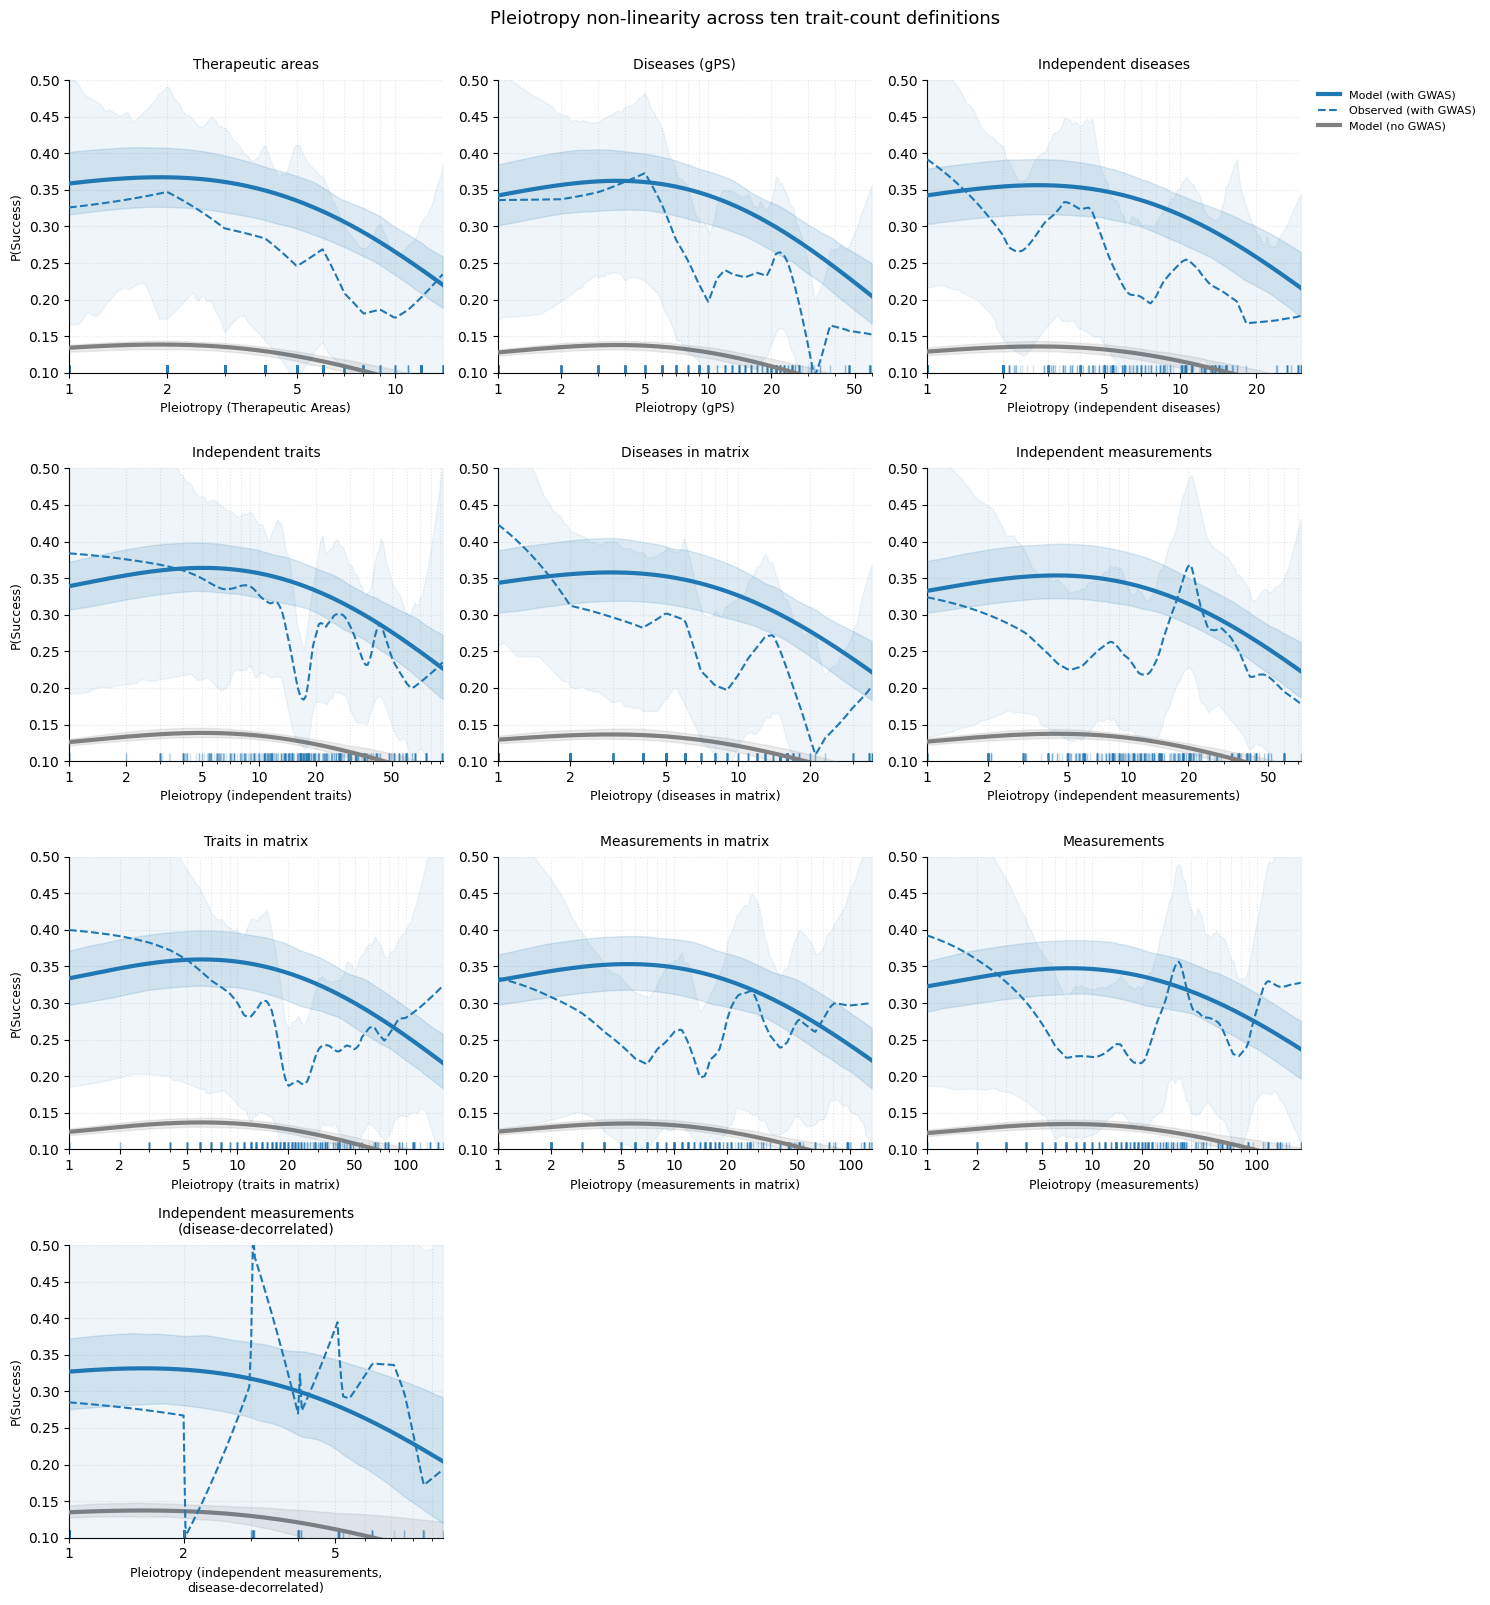

saved figure_sr6.pdf


In [6]:
def plot_panel(ax, curve, xlabel, title, show_legend=False, show_ylabel=False):
    x_grid = curve["x_grid"]
    ax.plot(x_grid, curve["model_gs1"], color="#1f77b4", lw=3, label="Model (with GWAS)", zorder=10)
    ax.fill_between(x_grid, curve["ci_gs1"][0], curve["ci_gs1"][1], color="#1f77b4", alpha=0.15, zorder=9)

    ax.plot(x_grid, curve["lowess_gs1"], color="#1f77b4", lw=1.5, ls="--", label="Observed (with GWAS)", zorder=8)
    ax.fill_between(x_grid, curve["lowess_ci_gs1"][0], curve["lowess_ci_gs1"][1], color="#1f77b4", alpha=0.07, zorder=7)

    ax.plot(x_grid, curve["model_gs0"], color="gray", lw=3, label="Model (no GWAS)", zorder=6)
    ax.fill_between(x_grid, curve["ci_gs0"][0], curve["ci_gs0"][1], color="gray", alpha=0.15, zorder=5)

    ax.plot(curve["rug"], np.full(len(curve["rug"]), 0.105), "|", color="#1f77b4", alpha=0.2, zorder=1)

    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xticks([t for t in [1, 2, 5, 10, 20, 50, 100, 200] if curve["x_min"] <= t <= curve["x_max"]])
    ax.set_xlim(curve["x_min"], curve["x_max"])
    ax.set_ylim(0.1, 0.5)

    ax.set_xlabel(xlabel, fontsize=9)
    if show_ylabel:
        ax.set_ylabel("P(Success)", fontsize=9)
    ax.set_title(title, fontsize=10, pad=8)
    ax.grid(True, which="both", ls=":", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    if show_legend:
        ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)


fig, axes = plt.subplots(4, 3, figsize=(15, 16))
for i, spec in enumerate(METRIC_SPECS):
    plot_panel(
        axes.flat[i],
        curves[spec["label"]],
        spec["xlabel"],
        spec["label"],
        show_legend=(i == 2),
        show_ylabel=(i % 3 == 0),
    )
for j in range(len(METRIC_SPECS), axes.size):
    axes.flat[j].axis("off")

fig.suptitle("Pleiotropy non-linearity across ten trait-count definitions", fontsize=13, y=1.0)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "figure_sr6.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("saved figure_sr6.pdf")

## Reading

Panels 1-2 are the main-text figure's two counts. Panels 3 and 5 — independent diseases, and diseases
restricted to the genetic-correlation matrix — keep the rise-then-fall shape and a clearly separated
no-GWAS baseline, so the non-linearity is not an artefact of counting correlated diseases twice.
Panels 4 and 6-10, the counts that admit measurements, flatten: the measurement axis carries the
relation much more weakly, which is the point Supplementary Results 14.3 makes from the table above
this figure.